
LOADING AND PREPARING DATA
Using 578 data points for analysis

AGE VS ACCRETION RATE CORRELATION

Age vs Accretion Rate:
  Slope: -0.145
  Correlation (r): -0.139
  R²: 0.019 (1.9% variance explained)
  p-value: 8.12e-04

MASS VS ACCRETION RATE CORRELATION

Mass vs Accretion Rate:
  Slope: 0.423
  Correlation (r): 0.317
  R²: 0.100 (10.0% variance explained)
  p-value: 5.84e-15

INTERPRETATION
1. Accretion rate declines with stellar age (expected for disk dissipation)
2. Higher mass stars have higher accretion rates (expected from gravitational potential)


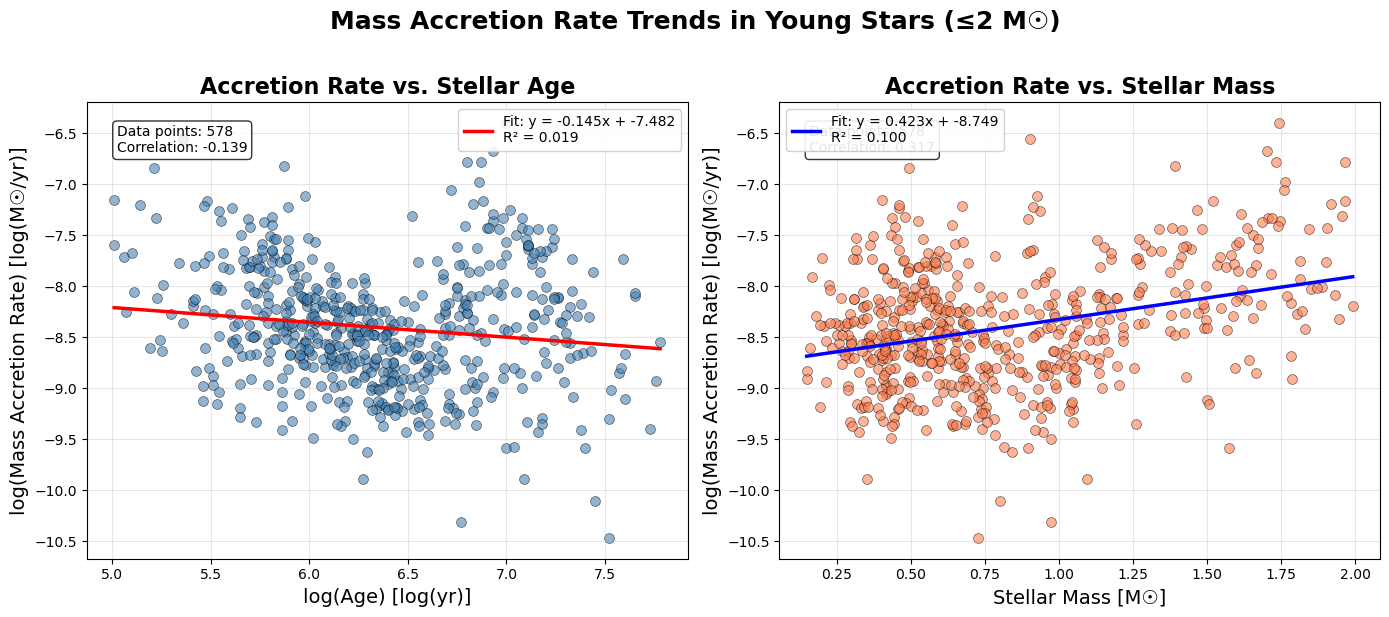

In [1]:
"""
Correlation Analysis - Age and Mass Trends in Mass Accretion Rate
Updated: Jun 29 2026

Input Files:
compilation_Venuti_2024_Serna_2021.csv

Output Files:
None (plots displayed as output)

This has 4 sections:
1 - Data loading and preparation
2 - Age vs accretion rate correlation
3 - Mass vs accretion rate correlation
4 - Visualize correlations
"""

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import linregress
import os

# Set random seed for reproducibility
np.random.seed(42)


def load_and_filter_data(file_path):
    """
    Load the dataset and apply filters for stellar mass and data quality.
    
    Parameters:
        file_path (str): Path to the CSV file
        
    Returns:
        pd.DataFrame: Filtered dataframe with required columns
    """
    if not os.path.exists(file_path):
        raise FileNotFoundError(f"File not found: {file_path}")
    
    df = pd.read_csv(file_path)
    
    # Filter for stars ≤2 solar masses
    df = df[df['Mstar'] <= 2.0]
    
    # Remove rows with missing data
    df = df.dropna(subset=['logAge', 'Mstar', 'logMacc'])
    
    return df


def perform_correlation(x, y, label):
    """
    Perform linear regression and print correlation statistics.
    
    Parameters:
        x (array-like): Independent variable
        y (array-like): Dependent variable
        label (str): Description of the relationship
        
    Returns:
        tuple: (slope, intercept, r_value, p_value, std_err)
    """
    slope, intercept, r_value, p_value, std_err = linregress(x, y)
    
    print(f"\n{label}:")
    print(f"  Slope: {slope:.3f}")
    print(f"  Correlation (r): {r_value:.3f}")
    print(f"  R²: {r_value**2:.3f} ({r_value**2*100:.1f}% variance explained)")
    print(f"  p-value: {p_value:.2e}")
    
    return slope, intercept, r_value, p_value, std_err


def add_stats_box(ax, text, x_pos=0.05, y_pos=0.95):
    """
    Add a statistics box to a plot.
    
    Parameters:
        ax (matplotlib.axes.Axes): The axes to add the box to
        text (str): Text to display in the box
        x_pos (float): X position in axes coordinates
        y_pos (float): Y position in axes coordinates
    """
    ax.text(x_pos, y_pos, text, transform=ax.transAxes,
            verticalalignment='top', fontsize=10,
            bbox=dict(boxstyle='round', facecolor='white', alpha=0.8))


# ============================================================================
# Section 1: LOAD AND PREPARE DATA
# ============================================================================
print("\n" + "="*60)
print("LOADING AND PREPARING DATA")
print("="*60)

file_path = 'compilation_Venuti_2024_Serna_2021.csv'
df = load_and_filter_data(file_path)

print(f"Using {len(df)} data points for analysis")

x_age = df['logAge'].values
x_mass = df['Mstar'].values
y_macc = df['logMacc'].values

# ============================================================================
# Section 2: AGE VS ACCRETION RATE CORRELATION
# ============================================================================
print("\n" + "="*60)
print("AGE VS ACCRETION RATE CORRELATION")
print("="*60)

slope_age, intercept_age, r_value_age, p_value_age, _ = perform_correlation(
    x_age, y_macc, "Age vs Accretion Rate"
)

# ============================================================================
# Section 3: MASS VS ACCRETION RATE CORRELATION
# ============================================================================
print("\n" + "="*60)
print("MASS VS ACCRETION RATE CORRELATION")
print("="*60)

slope_mass, intercept_mass, r_value_mass, p_value_mass, _ = perform_correlation(
    x_mass, y_macc, "Mass vs Accretion Rate"
)

# ============================================================================
# Section 4: VISUALIZE CORRELATIONS
# ============================================================================
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 6))

# Plot 1: Age vs Accretion Rate
ax1.scatter(df['logAge'], df['logMacc'], 
            alpha=0.6, s=50, c='steelblue', edgecolors='black', linewidth=0.5)

x_fit_age = np.linspace(x_age.min(), x_age.max(), 100)
y_fit_age = slope_age * x_fit_age + intercept_age

ax1.plot(x_fit_age, y_fit_age, 'r-', linewidth=2.5, 
         label=f'Fit: y = {slope_age:.3f}x + {intercept_age:.3f}\nR² = {r_value_age**2:.3f}')

ax1.set_xlabel('log(Age) [log(yr)]', fontsize=14)
ax1.set_ylabel('log(Mass Accretion Rate) [log(M☉/yr)]', fontsize=14)
ax1.set_title('Accretion Rate vs. Stellar Age', fontsize=16, fontweight='bold')
ax1.grid(True, alpha=0.3)
ax1.legend(loc='upper right', fontsize=10, framealpha=0.9)

add_stats_box(ax1, f'Data points: {len(df)}\nCorrelation: {r_value_age:.3f}')

# Plot 2: Mass vs Accretion Rate
ax2.scatter(df['Mstar'], df['logMacc'], 
            alpha=0.6, s=50, c='coral', edgecolors='black', linewidth=0.5)

x_fit_mass = np.linspace(x_mass.min(), x_mass.max(), 100)
y_fit_mass = slope_mass * x_fit_mass + intercept_mass

ax2.plot(x_fit_mass, y_fit_mass, 'b-', linewidth=2.5, 
         label=f'Fit: y = {slope_mass:.3f}x + {intercept_mass:.3f}\nR² = {r_value_mass**2:.3f}')

ax2.set_xlabel('Stellar Mass [M☉]', fontsize=14)
ax2.set_ylabel('log(Mass Accretion Rate) [log(M☉/yr)]', fontsize=14)
ax2.set_title('Accretion Rate vs. Stellar Mass', fontsize=16, fontweight='bold')
ax2.grid(True, alpha=0.3)
ax2.legend(loc='upper left', fontsize=10, framealpha=0.9)

add_stats_box(ax2, f'Data points: {len(df)}\nCorrelation: {r_value_mass:.3f}')

plt.suptitle('Mass Accretion Rate Trends in Young Stars (≤2 M☉)', 
             fontsize=18, fontweight='bold', y=1.02)
plt.tight_layout()

print("\n" + "="*60)
print("INTERPRETATION")
print("="*60)
print("1. Accretion rate declines with stellar age (expected for disk dissipation)")
print("2. Higher mass stars have higher accretion rates (expected from gravitational potential)")

plt.show()